In [6]:
import numpy as np
import matplotlib.pyplot as plt

from helpers.geometry_map import make_geometry_map, build_dist_tree_from_map
from helpers.data_transforms import load_in_data

from tqdm import tqdm

In [2]:
geo_map_path = "/pscratch/sd/r/rmastand/muon_collider/geometry_map.txt"

# make_geometry_map(
#     df,
#     collections,
#     geo_map_path,
#     num_events_per_col=1_000_000,
    
# )

In [3]:
tree_map, cellid_layer_map = build_dist_tree_from_map(geo_map_path)

Loaded geometry map with 6000000 hits across 6 collections


In [4]:

ZUKO_ID = "NCSF"
NAME = "M_8192_rphi_cond3"
NUM_COND_INPUTS = 3

FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []


collections = [
    "InnerTrackerBarrelCollection",
    "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
    "VertexEndcapCollection",
]


feature_order_endcap = [0, 4, 1, 2, 3,  5, 6]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6
}

feature_order_barrel = [0, 4, 2, 3, 1,  5, 6]
feature_indices_dict_barrel = {
    "r":4,
    "phi": 2,
    "z":3,
    "side":5,
    "layer":6
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}



In [7]:
# load in samples

all_data_dir, all_samples_dir = {}, {}


for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1, NUM_COND_INPUTS, feature_order_dict[col_name])
    all_data_dir[col_name] = X
    all_samples_dir[col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")
   

In [23]:



def get_col_hits_per_layer(data):

    

    col_hits_per_layer = {col: {} for col in collections}
    dists  = {col: {} for col in collections}
    cell_ids = {col: {} for col in collections}

    
    
    for col_name in collections:
    
    
        # -----------------------------
        # 1. Extract coordinates
        # -----------------------------
        r = data[col_name][:,feature_indices_dict[col_name]["r"]]
        phi = data[col_name][:,feature_indices_dict[col_name]["phi"]]
        z = data[col_name][:,feature_indices_dict[col_name]["z"]]
        x = r*np.cos(phi)
        y = r*np.sin(phi)
        
        points = np.stack([x,y,z], axis=1)   # shape (N, 3)
    
        # -----------------------------
        # 2. Mask out NaNs / infs
        # -----------------------------
        valid_mask = np.isfinite(points).all(axis=1)
        points_valid = points[valid_mask]
    
        # Skip if nothing valid
        if len(points_valid) == 0:
            continue
    
        # -----------------------------
        # 3. Batch KDTree query
        # -----------------------------
        dists_batch, idx_batch = tree_map[col_name].query(points_valid)
    
        # -----------------------------
        # 4. Remove invalid KDTree hits
        # -----------------------------
        valid_idx_mask = idx_batch < len(cellid_layer_map[col_name])
    
        idx_batch = idx_batch[valid_idx_mask]
        dists[col_name]  = dists_batch[valid_idx_mask]
    
        # -----------------------------
        # 5. Map to (cell_id, layer)
        # -----------------------------
        cell_layer = cellid_layer_map[col_name][idx_batch]
        layers = cell_layer[:, 1]
        cell_ids[col_name] = cell_layer[:, 0]
    
        # -----------------------------
        # 6. Count hits per layer (vectorized)
        # -----------------------------
        unique_layers, counts = np.unique(layers, return_counts=True)
    
        for layer, count in zip(unique_layers, counts):
            col_hits_per_layer[col_name][layer] = (
                col_hits_per_layer[col_name].get(layer, 0) + count
            )


    return col_hits_per_layer, dists, cell_ids

In [24]:
col_hits_per_layer_truth, dists_truth, cell_ids_truth = get_col_hits_per_layer(all_data_dir)
col_hits_per_layer_samples, dists_samples, cell_ids_samples = get_col_hits_per_layer(all_samples_dir)



ITBC
(3926196, 3)
ITEC
(1614679, 3)
OTBC
(3280678, 3)
OTEC
(1465825, 3)
VBC
(2129166, 3)
VEC
(4096371, 3)
ITBC
(3926196, 3)
ITEC
(1614679, 3)
OTBC
(3280678, 3)
OTEC
(1465825, 3)
VBC
(2129166, 3)
VEC
(4096371, 3)


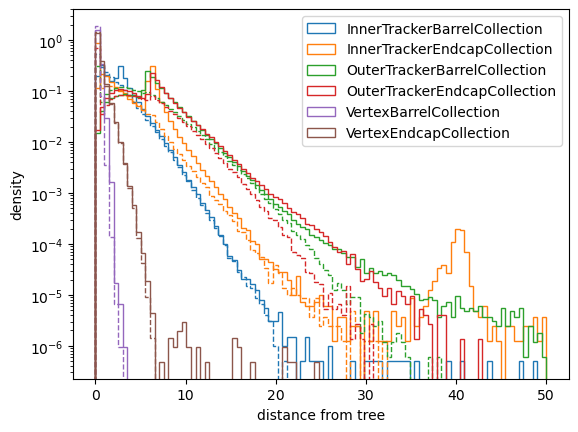

In [28]:



plt.figure()
for i, col in enumerate(collections):
    plt.hist(dists_truth[col], bins = np.linspace(0, 50, 100), histtype = "step", density = True, linestyle = "dashed", color = f"C{i}")
    plt.hist(dists_samples[col], bins = np.linspace(0, 50, 100), histtype = "step", density = True, color = f"C{i}", label = col)
plt.yscale("log")
plt.xlabel("distance from tree")
plt.ylabel("density")
plt.legend()
plt.show()

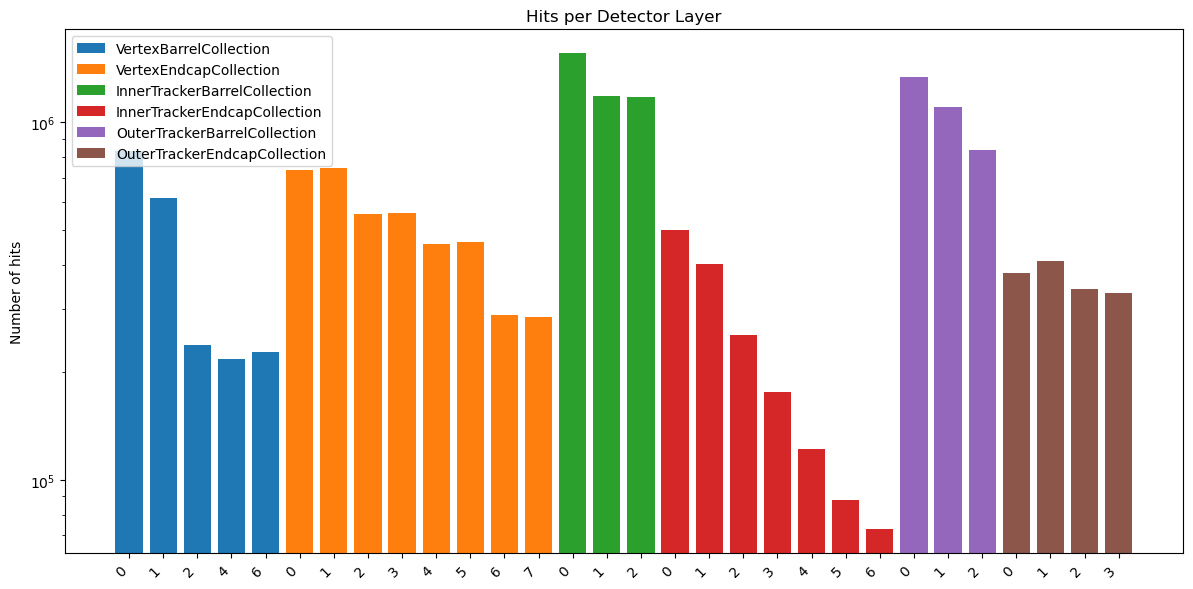

In [31]:
collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]

# Prepare x positions
width = 0.1  # width of each bar
x_offsets = np.arange(0, len(col_hits_per_layer[collections_order[0]]))  # base positions for first collection

fig, ax = plt.subplots(figsize=(12, 6))

# Keep track of total x positions
x_pos = 0
x_labels = []
x_ticks = []

for coll in collections_order:
    layers = sorted(col_hits_per_layer_samples[coll].keys())  # sort layers numerically
    counts = [col_hits_per_layer_samples[coll][l] for l in layers]

    # compute positions for this collection
    positions = x_pos + np.arange(len(layers))
    ax.bar(positions, counts, width=0.8, label=coll)
    
    # collect labels and ticks
    x_labels.extend([f"{l}" for l in layers])
    x_ticks.extend(positions)
    
    # update x_pos for next collection to avoid overlap
    x_pos = positions[-1] + 1  # add gap between collections

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel("Number of hits")
ax.set_title("Hits per Detector Layer")
ax.legend()
plt.tight_layout()
plt.yscale("log")
plt.savefig("figures/hits_per_detector_layer.png")
plt.show()

In [48]:


for col in collections_order:
    loc = np.concatenate([all_samples_dir[col], cell_ids_samples[col].reshape(-1,1)], axis = 1)

    np.save(f"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/{col}.npy", loc)
    print(loc.shape)

(2129166, 8)
(4096371, 8)
(3926196, 8)
(1614679, 8)
(3280678, 8)
(1465825, 8)


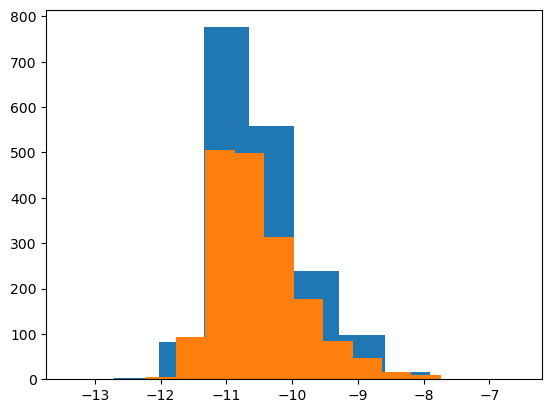

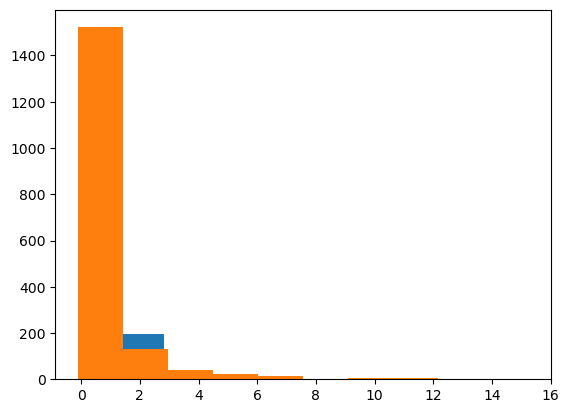

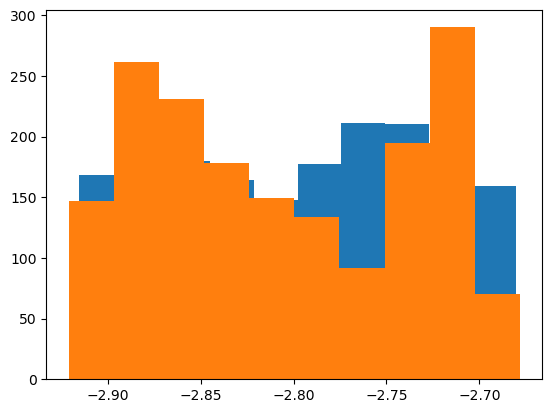

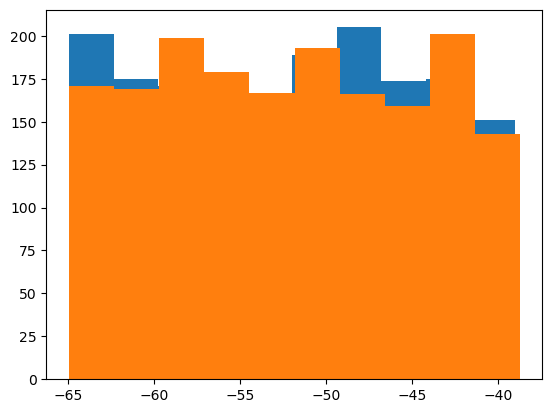

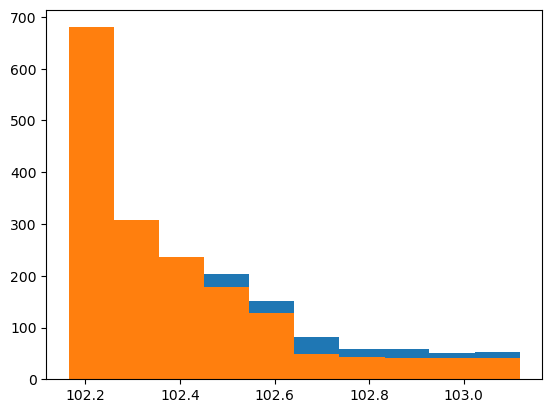

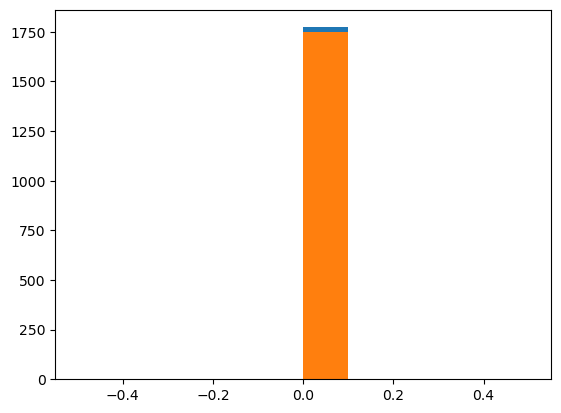

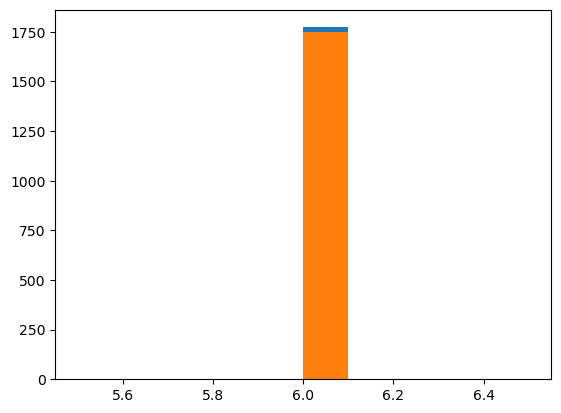

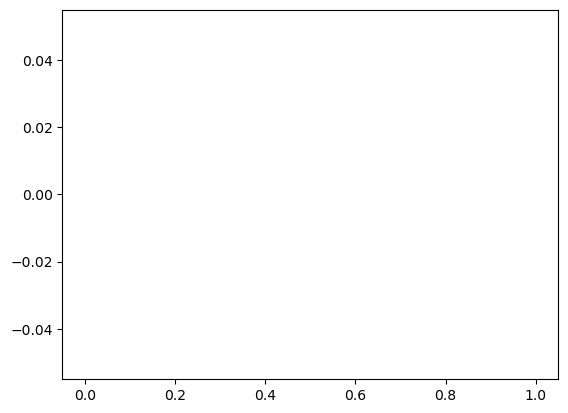

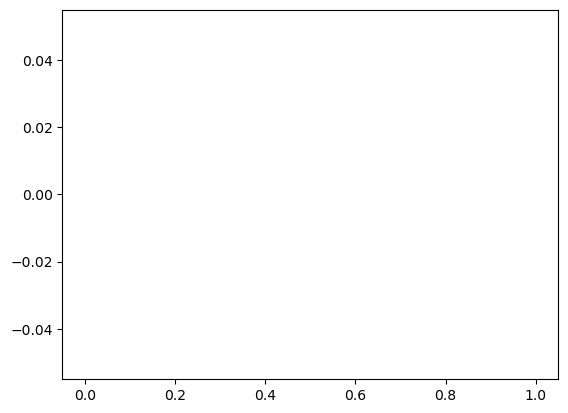

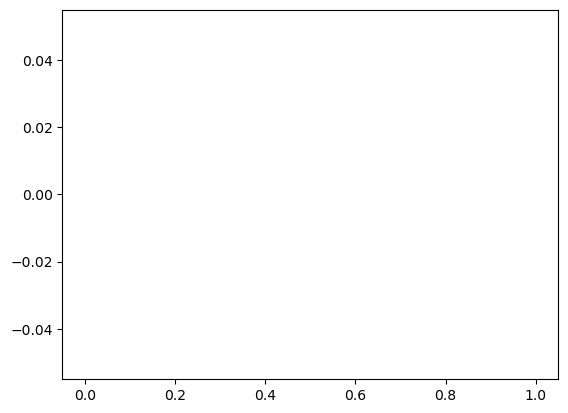

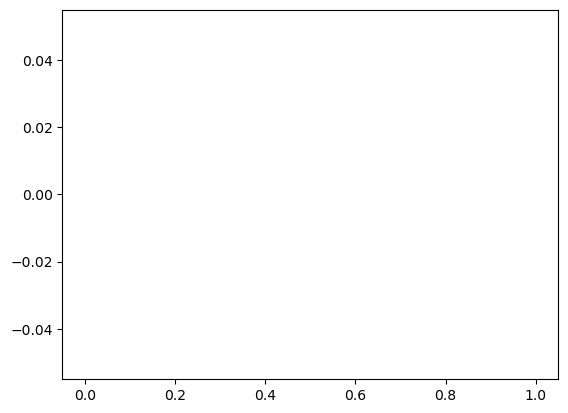

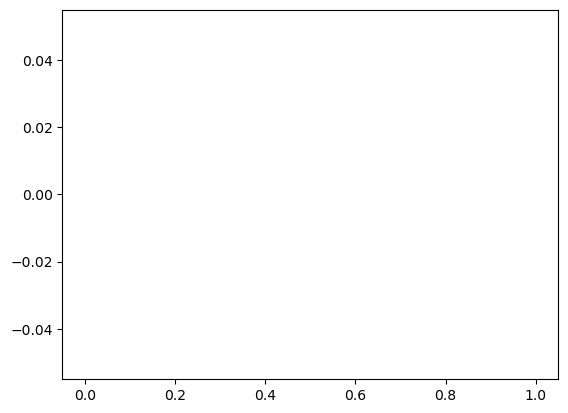

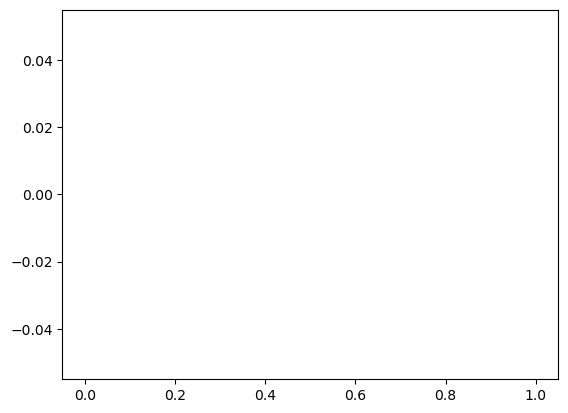

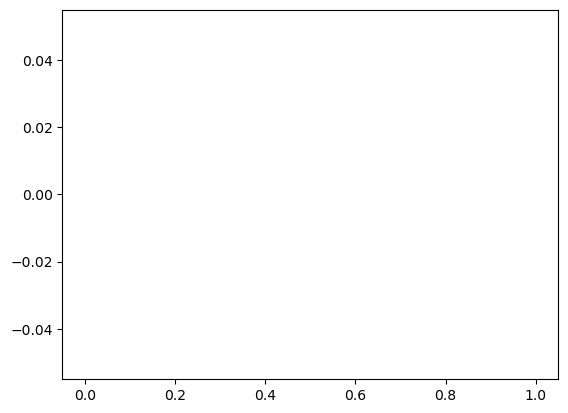

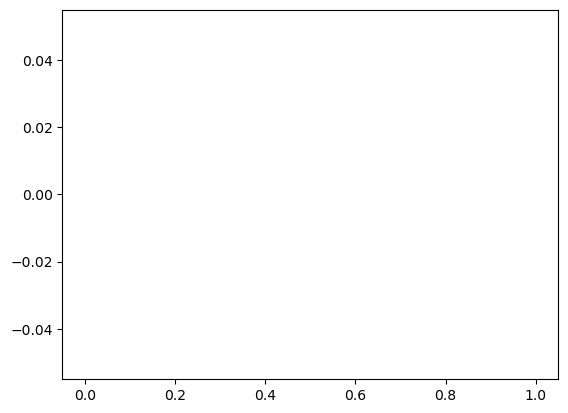

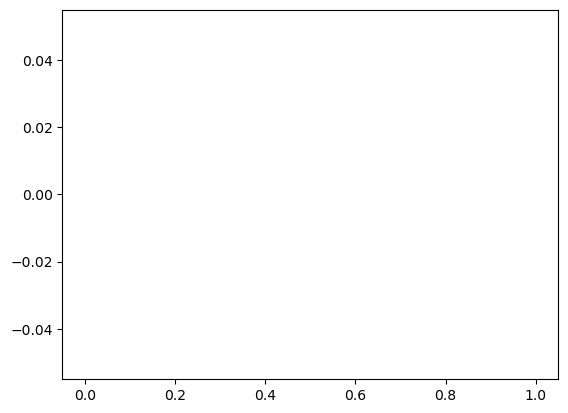

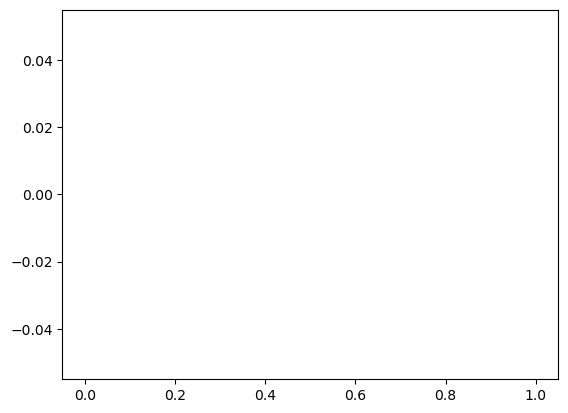

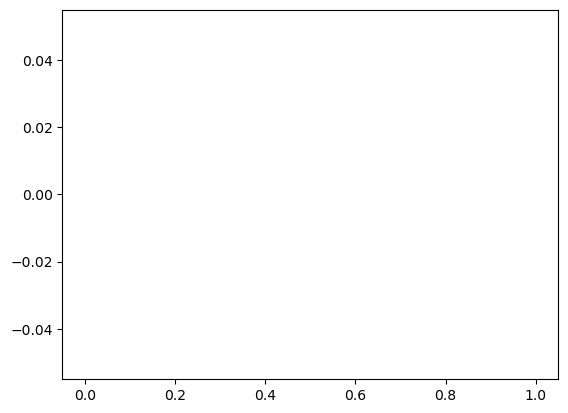

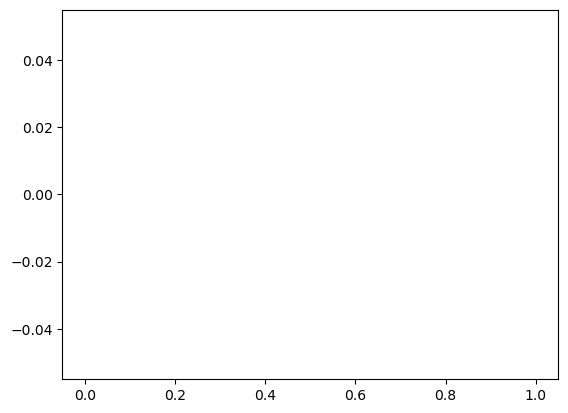

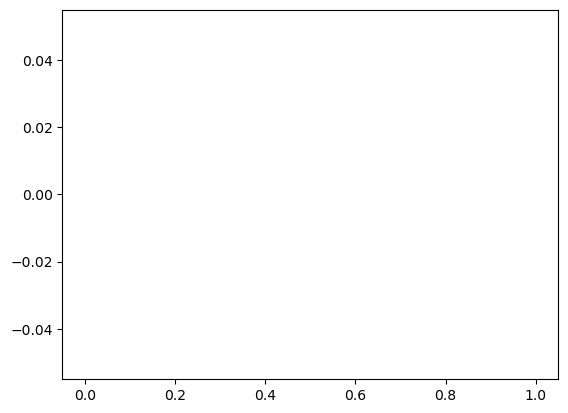

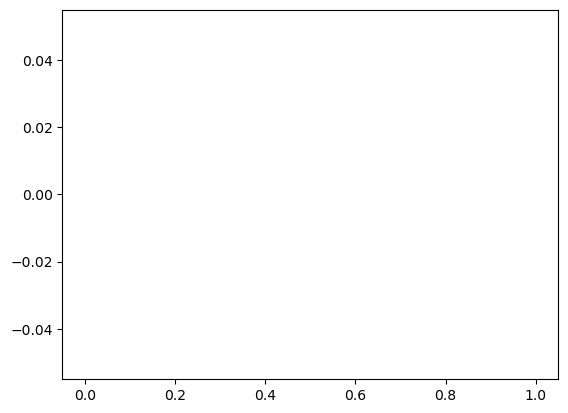

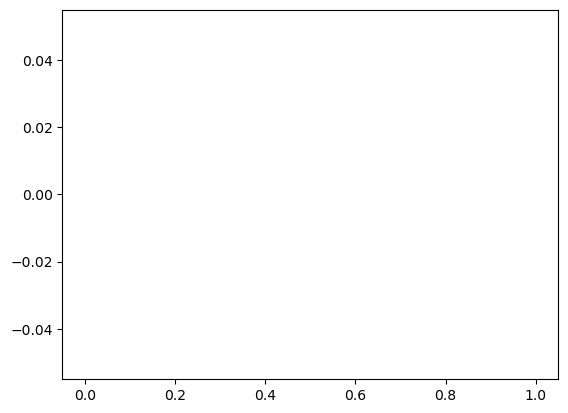

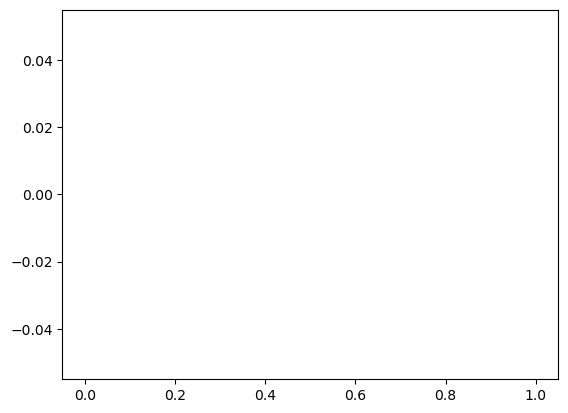

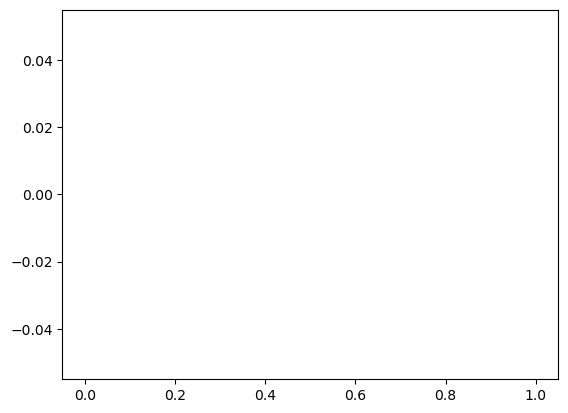

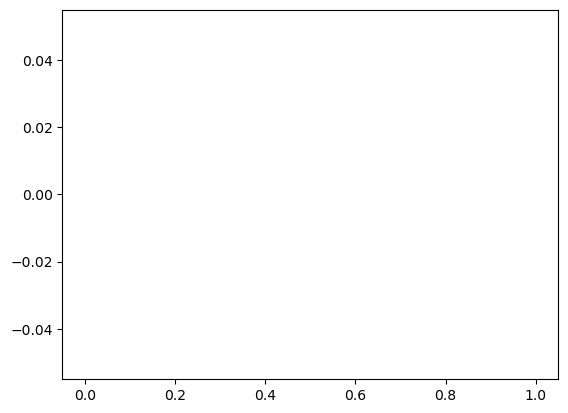

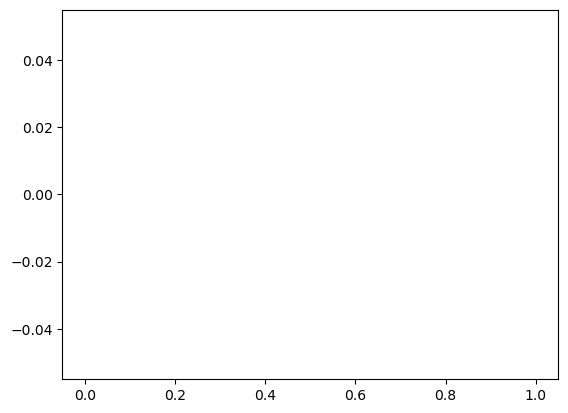

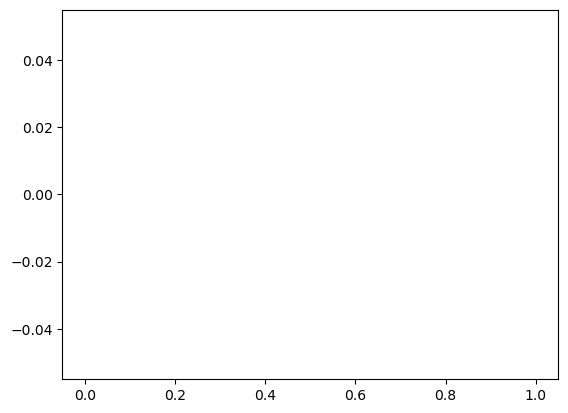

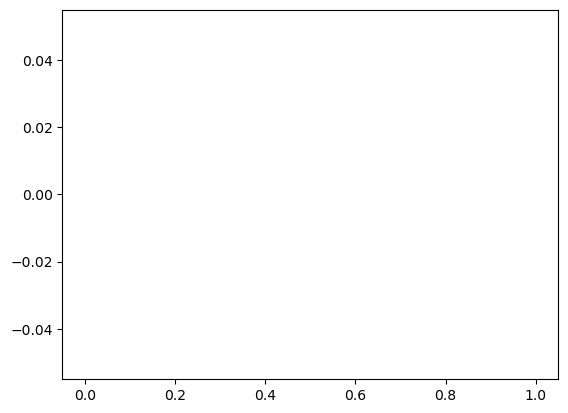

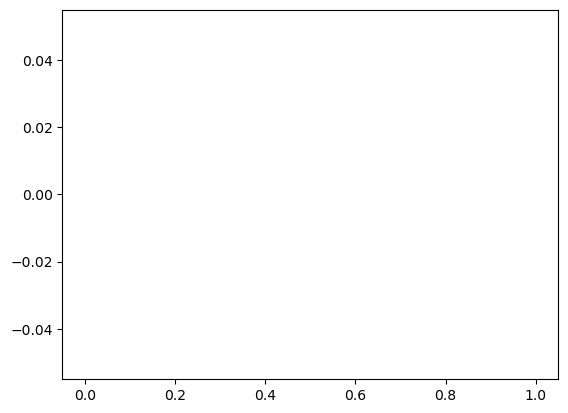

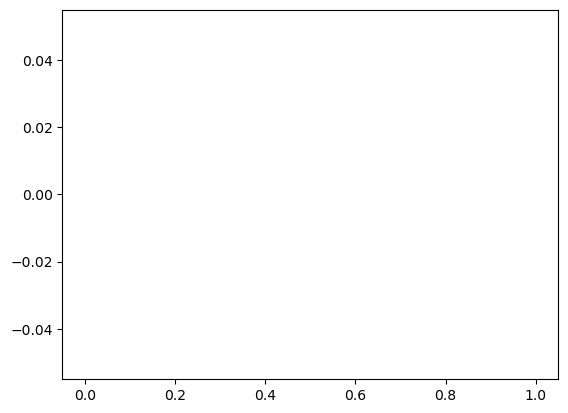

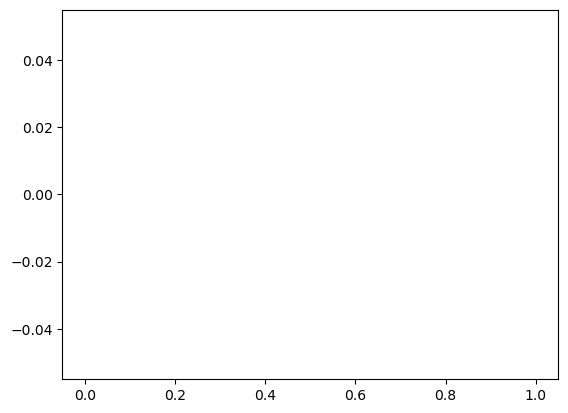

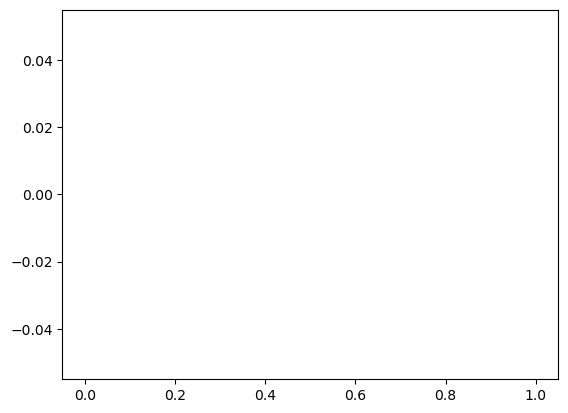

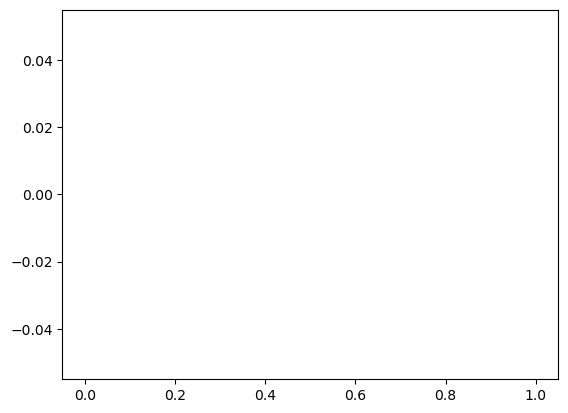

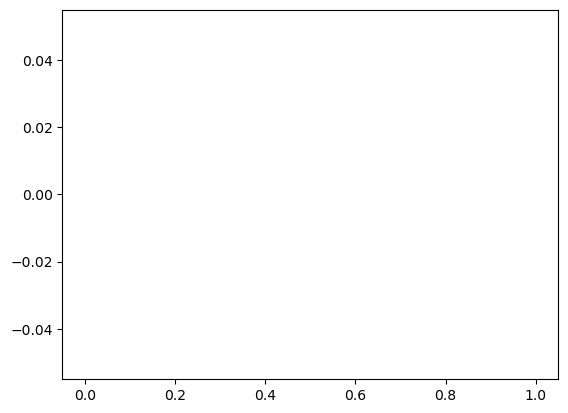

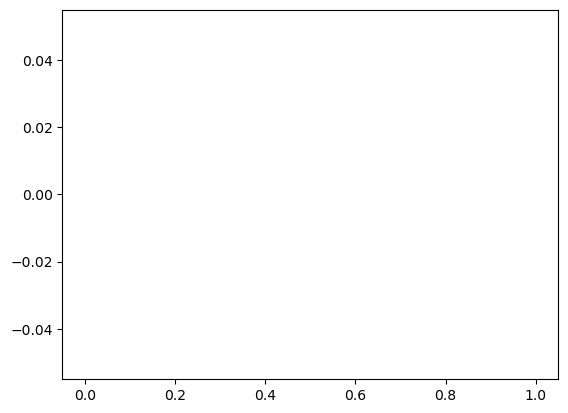

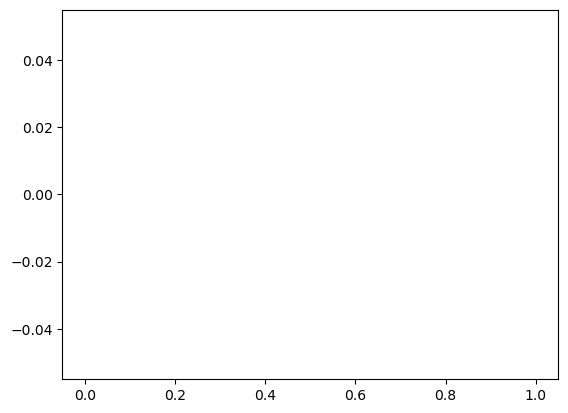

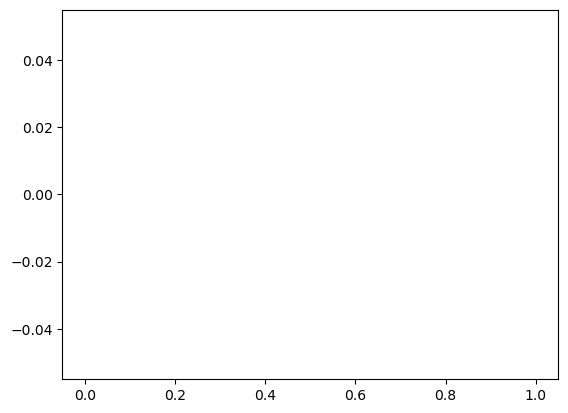

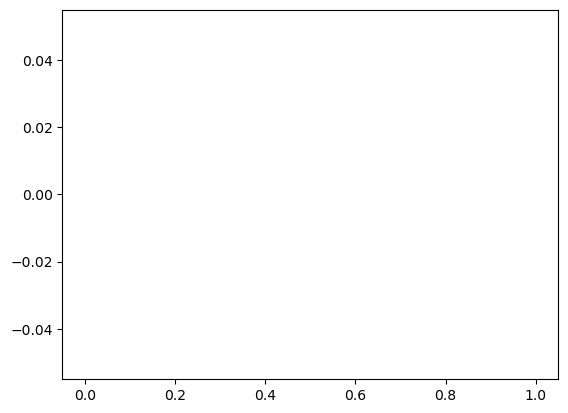

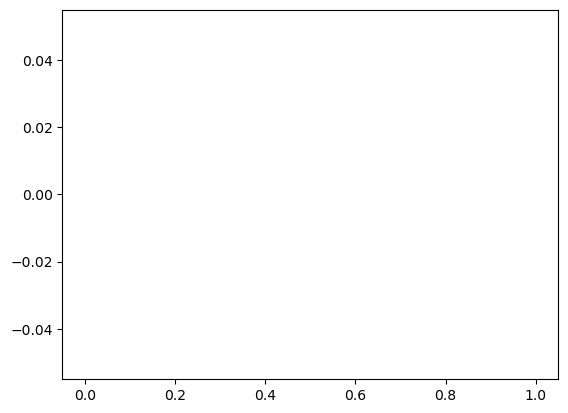

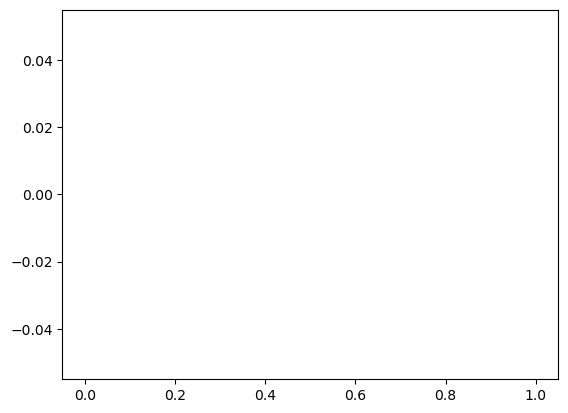

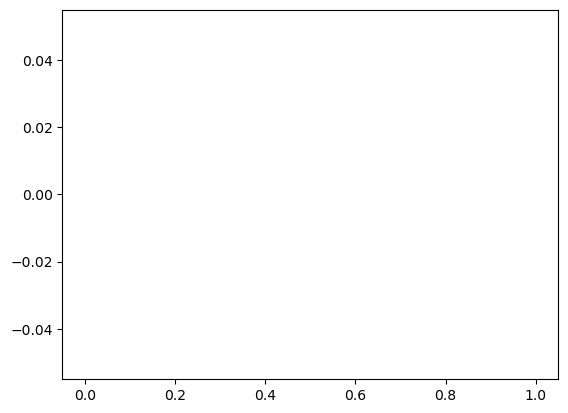

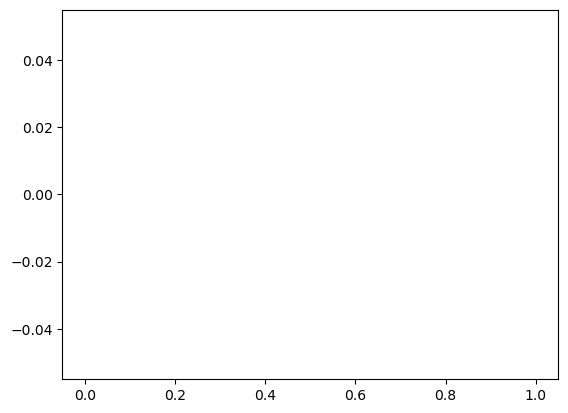